In [ ]:
import os
!pip install -q kagglehub

import kagglehub

dataset_path = kagglehub.dataset_download('andrewmvd/hard-hat-detection')
print('Dataset downloaded to:', dataset_path)

target = '/content/hard-hat-detection'
if not os.path.exists(target):
    os.symlink(dataset_path, target)
print('Dataset path:', target)


# Preparation

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import xml.etree.ElementTree as ET
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

print('='*60)
print('  ENVIRONMENT INFO')
print('='*60)
print(f'TensorFlow version : {tf.__version__}')
print(f'Keras version      : {keras.__version__}')
print(f'NumPy version      : {np.__version__}')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f'\n GPU tersedia: {len(gpus)} GPU(s) — memory growth enabled untuk semua')
        for g in gpus:
            print(f'   {g.name}')
    except RuntimeError as e:
        print(f'\n️  GPU memory growth error: {e}')
else:
    print('\n️  Tidak ada GPU, menggunakan CPU')

print('='*60)

2026-05-05 08:01:58.843943: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777968119.434287      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777968119.539549      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777968120.670134      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777968120.670178      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777968120.670181      23 computation_placer.cc:177] computation placer alr

  ENVIRONMENT INFO
TensorFlow version : 2.19.0
Keras version      : 3.10.0
NumPy version      : 2.0.2

 GPU tersedia: 2 GPU(s) — memory growth enabled untuk semua
   /physical_device:GPU:0
   /physical_device:GPU:1


# Konfigurasi Dataset

In [ ]:
DATASET_PATH = '/content/hard-hat-detection'

IMG_SIZE     = (64, 64)
IMG_H, IMG_W = IMG_SIZE
IMG_CHANNELS = 3
INPUT_SHAPE  = (IMG_H, IMG_W, IMG_CHANNELS)

# mapping
LABEL_MAP = {
    'helmet': 0,
    'head'  : 1,
}
CLASS_NAMES = ['helmet (Pakai Helm)', 'head (Tanpa Helm)']
NUM_CLASSES = 2

EPOCHS       = 50
BATCH_SIZE   = 32
VAL_SPLIT    = 0.20
TEST_SPLIT   = 0.20
RANDOM_STATE = 42

# seed untuk reproducibility
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print('='*60)
print('  KONFIGURASI BERHASIL DIMUAT')
print('='*60)
print(f'Dataset Path  : {DATASET_PATH}')
print(f'Image Size    : {IMG_SIZE}')
print(f'Input Shape   : {INPUT_SHAPE}')
print(f'Num Classes   : {NUM_CLASSES}')
print(f'Epochs        : {EPOCHS}')
print(f'Batch Size    : {BATCH_SIZE}')
print(f'Val Split     : {VAL_SPLIT*100:.0f}%')
print(f'Test Split    : {TEST_SPLIT*100:.0f}%')
print(f'Label Map     : {LABEL_MAP}')
print('='*60)

  KONFIGURASI BERHASIL DIMUAT
Dataset Path  : /kaggle/input/datasets/andrewmvd/hard-hat-detection
Image Size    : (64, 64)
Input Shape   : (64, 64, 3)
Num Classes   : 2
Epochs        : 50
Batch Size    : 32
Val Split     : 20%
Test Split    : 20%
Label Map     : {'helmet': 0, 'head': 1}


# Eksplorasi Dataset (EDA)

 Struktur folder dataset:
 hard-hat-detection/
     annotations/
         hard_hat_workers1531.xml
         hard_hat_workers4092.xml
         hard_hat_workers2006.xml
         hard_hat_workers3414.xml
         hard_hat_workers4190.xml
        ... dan 4995 file lainnya
     images/
         hard_hat_workers4991.png
         hard_hat_workers3833.png
         hard_hat_workers1675.png
         hard_hat_workers4122.png
         hard_hat_workers4460.png
        ... dan 4995 file lainnya

 Total file XML   : 5000
️  Total file gambar: 5000

 Distribusi Label (semua objek di dataset):
----------------------------------------
  helmet    : 18966 objek  (74.4%)
  head      :  5785 objek  (22.7%)
  person    :   751 objek  (2.9%)
  other     :     0 objek  (0.0%)

  Total dipakai (helmet+head): 24751
  Label person DIABAIKAN     : 751
----------------------------------------


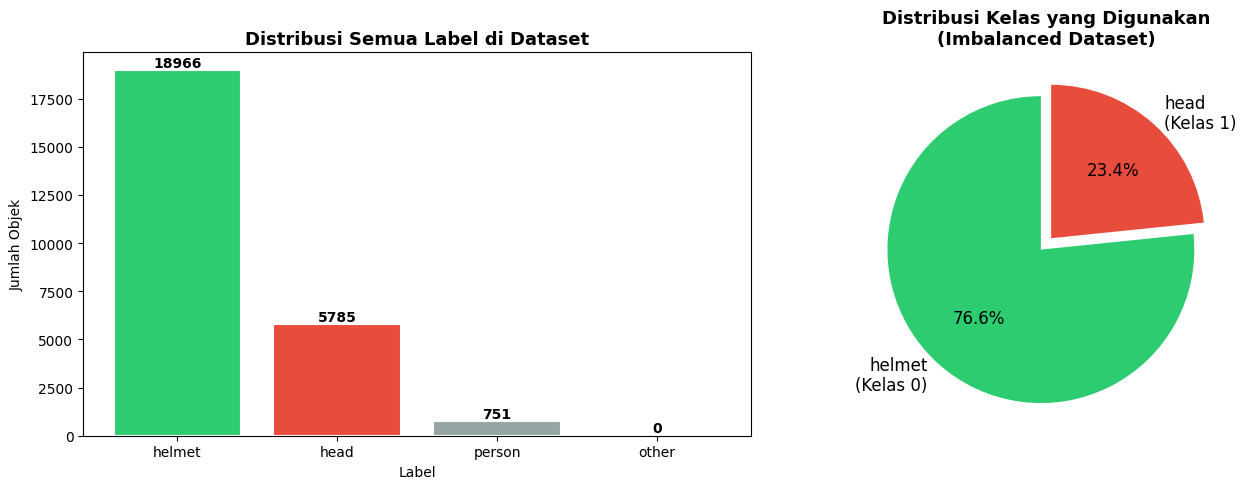

 Plot disimpan: 01_distribusi_label.png


In [ ]:
print(' Struktur folder dataset:')
for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f'{indent} {os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 4 * (level + 1)
        for f in files[:5]:
            print(f'{subindent} {f}')
        if len(files) > 5:
            print(f'{subindent}... dan {len(files)-5} file lainnya')
print()

# file XML & gambar
xml_files  = glob.glob(os.path.join(DATASET_PATH, '**', '*.xml'), recursive=True)
xml_files += glob.glob(os.path.join(DATASET_PATH, '*.xml'))

img_files  = glob.glob(os.path.join(DATASET_PATH, '**', '*.png'),  recursive=True)
img_files += glob.glob(os.path.join(DATASET_PATH, '**', '*.jpg'),  recursive=True)
img_files += glob.glob(os.path.join(DATASET_PATH, '**', '*.jpeg'), recursive=True)

xml_files = list(set(xml_files))
img_files = list(set(img_files))

print(f' Total file XML   : {len(xml_files)}')
print(f'️  Total file gambar: {len(img_files)}')

if len(xml_files) == 0:
    raise FileNotFoundError('XML files not found. Cek path dataset.')

#  distribusi label
label_counts = {'helmet': 0, 'head': 0, 'person': 0, 'other': 0}

for xml_path in xml_files:
    try:
        tree = ET.parse(xml_path)
        root_xml = tree.getroot()
        for obj in root_xml.findall('object'):
            name_tag = obj.find('name')
            if name_tag is None:
                continue
            name = name_tag.text.lower().strip()
            if name in label_counts:
                label_counts[name] += 1
            else:
                label_counts['other'] += 1
    except Exception:
        pass

print(f'\n Distribusi Label (semua objek di dataset):')
print('-'*40)

total_all  = sum(label_counts.values())
total_used = label_counts['helmet'] + label_counts['head']

if total_all == 0:
    raise ValueError('Tidak ada objek yang terbaca dari file XML.')

for k, v in label_counts.items():
    pct = (v / total_all) * 100
    print(f'  {k:<10}: {v:>5} objek  ({pct:.1f}%)')

print(f'\n  Total dipakai (helmet+head): {total_used}')
print(f'  Label person DIABAIKAN     : {label_counts["person"]}')
print('-'*40)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels_plot = list(label_counts.keys())
values_plot = list(label_counts.values())
colors = ['#2ecc71', '#e74c3c', '#95a5a6', '#bdc3c7']
axes[0].bar(labels_plot, values_plot, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Semua Label di Dataset', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Jumlah Objek')
for i, v in enumerate(values_plot):
    axes[0].text(i, v + max(values_plot)*0.01, str(v), ha='center', fontweight='bold')

used_labels = ['helmet\n(Kelas 0)', 'head\n(Kelas 1)']
used_values = [label_counts['helmet'], label_counts['head']]

if all(v > 0 for v in used_values):
    axes[1].pie(
        used_values, labels=used_labels, colors=['#2ecc71', '#e74c3c'],
        autopct='%1.1f%%', startangle=90, explode=(0.05, 0.05),
        textprops={'fontsize': 12}
    )
    axes[1].set_title('Distribusi Kelas yang Digunakan\n(Imbalanced Dataset)',
                      fontsize=13, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'Data tidak cukup', ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.savefig('/content/01_distribusi_label.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Plot disimpan: 01_distribusi_label.png')

# Parsing XML & Ekstraksi Bounding Box

In [ ]:
# Parse boundingbox untuk crop area objek (bkn gambar penuh)
def parse_annotation(xml_path):
    """
    Parse file XML Pascal VOC.
    Return list of (image_path, xmin, ymin, xmax, ymax, label).
    Ambil koordinat bounding box untuk crop individual objek.
    Label 'person' DIABAIKAN.
    """
    records = []
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()

        filename = root.find('filename')
        if filename is None:
            return records

        fname      = filename.text.strip()
        fname_noext = os.path.splitext(fname)[0]
        img_exts   = ['.png', '.jpg', '.jpeg', '.PNG', '.JPG']
        img_path   = None

        # 1. Cari di folder images/
        images_dir = os.path.join(DATASET_PATH, 'images')
        for ext in img_exts:
            candidate = os.path.join(images_dir, fname_noext + ext)
            if os.path.exists(candidate):
                img_path = candidate
                break

        # 2. Fallback: folder yang sama dengan XML
        if img_path is None:
            base_dir = os.path.dirname(xml_path)
            for ext in img_exts:
                candidate = os.path.join(base_dir, fname_noext + ext)
                if os.path.exists(candidate):
                    img_path = candidate
                    break

        # 3. Fallback: glob rekursif — HANYA ekstensi gambar
        if img_path is None:
            matches = glob.glob(
                os.path.join(DATASET_PATH, '**', fname_noext + '.*'),
                recursive=True
            )
            img_matches = [m for m in matches
                           if os.path.splitext(m)[1].lower() in {'.png', '.jpg', '.jpeg'}]
            if img_matches:
                img_path = img_matches[0]

        if img_path is None:
            return records

        # Parse setiap objek beserta bounding box-nya
        for obj in root.findall('object'):
            name_tag = obj.find('name')
            if name_tag is None:
                continue
            name = name_tag.text.lower().strip()
            if name not in LABEL_MAP:
                continue

            bndbox = obj.find('bndbox')
            if bndbox is None:
                continue

            try:
                xmin = int(float(bndbox.find('xmin').text))
                ymin = int(float(bndbox.find('ymin').text))
                xmax = int(float(bndbox.find('xmax').text))
                ymax = int(float(bndbox.find('ymax').text))
            except (AttributeError, ValueError, TypeError):
                continue

            if xmax <= xmin or ymax <= ymin:
                continue

            label = LABEL_MAP[name]
            records.append((img_path, xmin, ymin, xmax, ymax, label))

    except Exception:
        pass

    return records

print(' Parsing XML annotations (dengan bounding box)...')

all_records = []
for i, xml_path in enumerate(xml_files):
    records = parse_annotation(xml_path)
    all_records.extend(records)
    if (i+1) % 500 == 0:
        print(f'   Progress: {i+1}/{len(xml_files)} XML | Records: {len(all_records)}')

print(f'\n Parsing selesai!')
print(f'   Total records (crop-label pairs): {len(all_records)}')

df = pd.DataFrame(all_records, columns=['image_path', 'xmin', 'ymin', 'xmax', 'ymax', 'label'])
df['label_name'] = df['label'].map({0: 'helmet', 1: 'head'})

print(f'\n Distribusi kelas:')
print(df['label_name'].value_counts())
print(f'\n{"="*50}')
print(df.head(10))

 Parsing XML annotations (dengan bounding box)...
   Progress: 500/5000 XML | Records: 2393
   Progress: 1000/5000 XML | Records: 5056
   Progress: 1500/5000 XML | Records: 7648
   Progress: 2000/5000 XML | Records: 9994
   Progress: 2500/5000 XML | Records: 12476
   Progress: 3000/5000 XML | Records: 14841
   Progress: 3500/5000 XML | Records: 17238
   Progress: 4000/5000 XML | Records: 19659
   Progress: 4500/5000 XML | Records: 22102
   Progress: 5000/5000 XML | Records: 24751

 Parsing selesai!
   Total records (crop-label pairs): 24751

 Distribusi kelas:
label_name
helmet    18966
head       5785
Name: count, dtype: int64

                                          image_path  xmin  ymin  xmax  ymax  \
0  /kaggle/input/datasets/andrewmvd/hard-hat-dete...   104   214   127   244   
1  /kaggle/input/datasets/andrewmvd/hard-hat-dete...   231   108   244   124   
2  /kaggle/input/datasets/andrewmvd/hard-hat-dete...   231    14   244    30   
3  /kaggle/input/datasets/andrewmvd/hard-ha

# Load & Preprocessing

 Loading & cropping 24751 objek dari bounding box...
   Setiap objek di-crop, lalu resize ke (64, 64)

   Progress: 1000/24751 | Loaded: 1000 | Skipped: 0
   Progress: 2000/24751 | Loaded: 2000 | Skipped: 0
   Progress: 3000/24751 | Loaded: 3000 | Skipped: 0
   Progress: 4000/24751 | Loaded: 4000 | Skipped: 0
   Progress: 5000/24751 | Loaded: 5000 | Skipped: 0
   Progress: 6000/24751 | Loaded: 6000 | Skipped: 0
   Progress: 7000/24751 | Loaded: 7000 | Skipped: 0
   Progress: 8000/24751 | Loaded: 8000 | Skipped: 0
   Progress: 9000/24751 | Loaded: 9000 | Skipped: 0
   Progress: 10000/24751 | Loaded: 10000 | Skipped: 0
   Progress: 11000/24751 | Loaded: 11000 | Skipped: 0
   Progress: 12000/24751 | Loaded: 12000 | Skipped: 0
   Progress: 13000/24751 | Loaded: 13000 | Skipped: 0
   Progress: 14000/24751 | Loaded: 14000 | Skipped: 0
   Progress: 15000/24751 | Loaded: 15000 | Skipped: 0
   Progress: 16000/24751 | Loaded: 16000 | Skipped: 0
   Progress: 17000/24751 | Loaded: 17000 | Skipped:

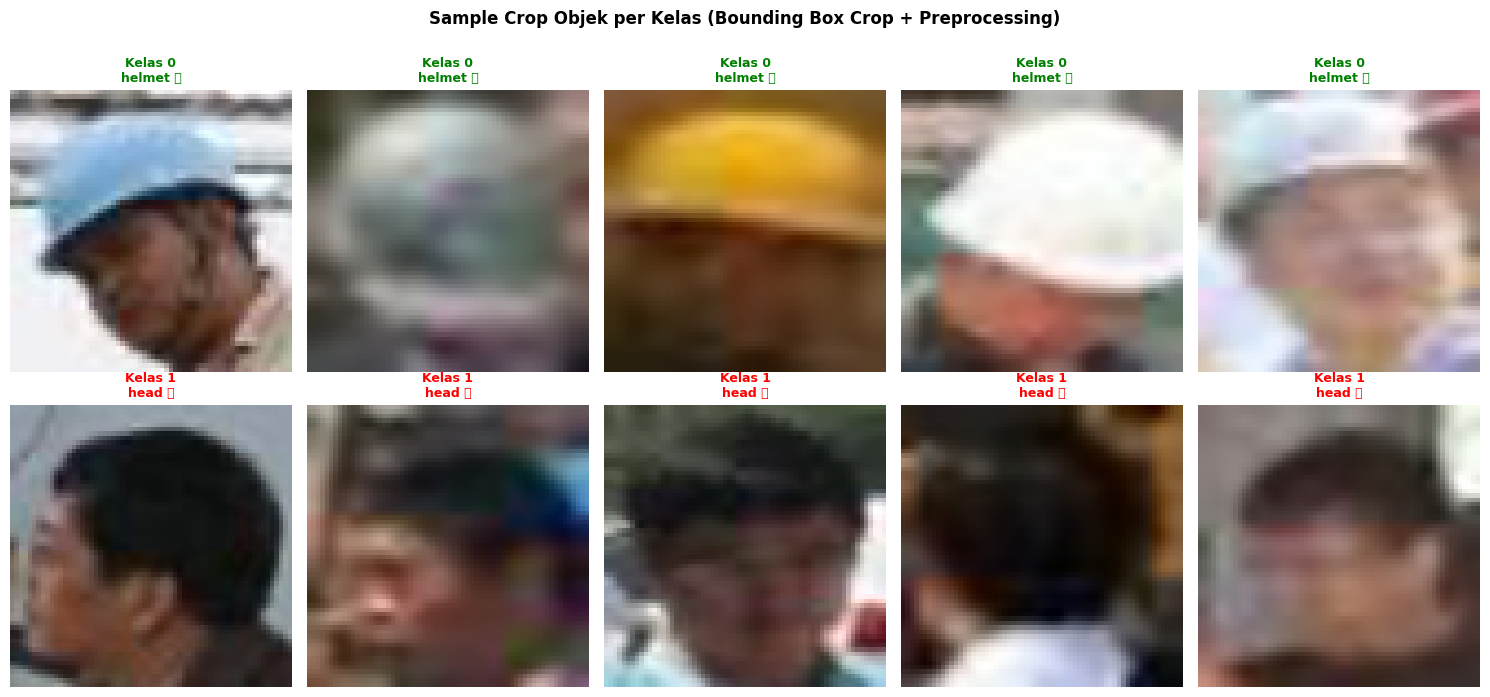

 Plot disimpan: 02_sample_gambar.png


In [ ]:
def load_and_preprocess_crop(img_path, xmin, ymin, xmax, ymax):
    """
    Load gambar, crop area bounding box, resize ke IMG_SIZE, normalisasi [0,1].
    Setiap objek di-crop secara individual — bukan load gambar penuh.
    Return numpy array shape (64, 64, 3) atau None jika gagal.
    """
    try:
        img = Image.open(img_path).convert('RGB')
        img_w, img_h = img.size

        # Clamp koordinat biar gk keluar batas gambar
        xmin = max(0, xmin)
        ymin = max(0, ymin)
        xmax = min(img_w, xmax)
        ymax = min(img_h, ymax)

        if xmax <= xmin or ymax <= ymin:
            return None

        crop = img.crop((xmin, ymin, xmax, ymax))
        crop = crop.resize(IMG_SIZE, Image.LANCZOS)
        img_array = np.array(crop, dtype=np.float32) / 255.0
        return img_array
    except Exception:
        return None


print(f' Loading & cropping {len(df)} objek dari bounding box...')
print(f'   Setiap objek di-crop, lalu resize ke {IMG_SIZE}\n')

X_list        = []
y_list        = []
img_path_list = []  # Simpan path gambar asal untuk per image split
skipped       = 0

for i, row in df.iterrows():
    img_array = load_and_preprocess_crop(
        row['image_path'], row['xmin'], row['ymin'], row['xmax'], row['ymax']
    )
    if img_array is not None:
        X_list.append(img_array)
        y_list.append(row['label'])
        img_path_list.append(row['image_path'])
    else:
        skipped += 1

    if (i+1) % 1000 == 0:
        print(f'   Progress: {i+1}/{len(df)} | Loaded: {len(X_list)} | Skipped: {skipped}')

X         = np.array(X_list, dtype=np.float32)
y         = np.array(y_list, dtype=np.int32)
img_paths = np.array(img_path_list)

print(f'\n Loading selesai!')
print(f'   Berhasil dimuat : {len(X_list)} crops')
print(f'   Gagal / skip    : {skipped}')

if len(X_list) == 0:
    raise RuntimeError(' Tidak ada crop yang berhasil di-load!')

print(f'\n Shape data:')
print(f'   X shape: {X.shape}')
print(f'   y shape: {y.shape}')

print(f'\n Distribusi final:')
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    name = 'helmet' if u == 0 else 'head'
    pct  = c / len(y) * 100
    print(f'   Kelas {u} ({name:>6}): {c:>5} samples ({pct:.1f}%)')

# sample crop
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

for cls in [0, 1]:
    idx_cls  = np.where(y == cls)[0]
    base_ax  = cls * 5
    cls_name = 'helmet ' if cls == 0 else 'head '

    if len(idx_cls) == 0:
        for j in range(5):
            axes[base_ax + j].set_title(f'Kelas {cls}\n(tidak ada data)', fontsize=9)
            axes[base_ax + j].axis('off')
        continue

    n_samples = min(5, len(idx_cls))
    samples   = np.random.choice(idx_cls, size=n_samples, replace=False)

    for j, idx in enumerate(samples):
        axes[base_ax + j].imshow(X[idx])
        axes[base_ax + j].set_title(
            f'Kelas {cls}\n{cls_name}',
            fontsize=9, fontweight='bold',
            color='green' if cls == 0 else 'red'
        )
        axes[base_ax + j].axis('off')

plt.suptitle('Sample Crop Objek per Kelas (Bounding Box Crop + Preprocessing)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/02_sample_gambar.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Plot disimpan: 02_sample_gambar.png')

# Split & Class Weight

In [ ]:
# Split berdasarkan gambar unik, bukan per-baris untuk mencegah data leakage (gambar yang sama di train & test)
unique_imgs = np.unique(img_paths)
print(f' Jumlah gambar unik : {len(unique_imgs)}')
print(f'   Total crops        : {len(X)}')
print(f'   Rata-rata crops/img: {len(X)/len(unique_imgs):.1f}')

# Split pada level gambar (bukan level baris)
np.random.seed(RANDOM_STATE)
perm                 = np.random.permutation(len(unique_imgs))
unique_imgs_shuffled = unique_imgs[perm]

n_test  = int(len(unique_imgs) * TEST_SPLIT)
n_val   = int((len(unique_imgs) - n_test) * VAL_SPLIT)

test_imgs  = set(unique_imgs_shuffled[:n_test])
val_imgs   = set(unique_imgs_shuffled[n_test : n_test + n_val])
train_imgs = set(unique_imgs_shuffled[n_test + n_val :])

print(f'\n Split gambar unik:')
print(f'   Train: {len(train_imgs)} gambar')
print(f'   Val  : {len(val_imgs)} gambar')
print(f'   Test : {len(test_imgs)} gambar')

# assign crops ke split berdasarkan gambar asalnya
mask_train = np.array([p in train_imgs for p in img_paths])
mask_val   = np.array([p in val_imgs   for p in img_paths])
mask_test  = np.array([p in test_imgs  for p in img_paths])

X_train, y_train = X[mask_train], y[mask_train]
X_val,   y_val   = X[mask_val],   y[mask_val]
X_test,  y_test  = X[mask_test],  y[mask_test]

print(f'\n{"="*60}')
print('  DATA SPLIT SUMMARY (Per-Image — No Data Leakage)')
print(f'{"="*60}')
print(f'  Total dataset  : {len(X):>6} crops')
print(f'  Train set      : {len(X_train):>6} crops ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Validation set : {len(X_val):>6} crops ({len(X_val)/len(X)*100:.1f}%)')
print(f'  Test set       : {len(X_test):>6} crops ({len(X_test)/len(X)*100:.1f}%)')
print(f'{"="*60}')

for split_name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    u, c = np.unique(y_split, return_counts=True)
    print(f'\n  {split_name} distribusi:')
    for ui, ci in zip(u, c):
        nm = 'helmet' if ui == 0 else 'head'
        print(f'    Kelas {ui} ({nm}): {ci} ({ci/len(y_split)*100:.1f}%)')

# Flatten untuk MLP
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat   = X_val.reshape(len(X_val),   -1)
X_test_flat  = X_test.reshape(len(X_test),  -1)

print(f'\n Shape setelah Flatten (untuk MLP):')
print(f'   X_train_flat: {X_train_flat.shape}')
print(f'   X_val_flat  : {X_val_flat.shape}')
print(f'   X_test_flat : {X_test_flat.shape}')

# Hitung Class Weight
class_weights_arr = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(y_train),
    y            = y_train
)
class_weight_dict = dict(enumerate(class_weights_arr))

print(f'\n️ Class Weight (untuk mengatasi Imbalanced Dataset):')
for cls_id, weight in class_weight_dict.items():
    nm = 'helmet' if cls_id == 0 else 'head'
    print(f'   Kelas {cls_id} ({nm}): {weight:.4f}')
print('\n Weight > 1.0 → kelas minoritas diberi penalti lebih besar')

 Jumlah gambar unik : 5000
   Total crops        : 24751
   Rata-rata crops/img: 5.0

 Split gambar unik:
   Train: 3200 gambar
   Val  : 800 gambar
   Test : 1000 gambar

  DATA SPLIT SUMMARY (Per-Image — No Data Leakage)
  Total dataset  :  24751 crops
  Train set      :  15986 crops (64.6%)
  Validation set :   3830 crops (15.5%)
  Test set       :   4935 crops (19.9%)

  Train distribusi:
    Kelas 0 (helmet): 12388 (77.5%)
    Kelas 1 (head): 3598 (22.5%)

  Val distribusi:
    Kelas 0 (helmet): 2919 (76.2%)
    Kelas 1 (head): 911 (23.8%)

  Test distribusi:
    Kelas 0 (helmet): 3659 (74.1%)
    Kelas 1 (head): 1276 (25.9%)

 Shape setelah Flatten (untuk MLP):
   X_train_flat: (15986, 12288)
   X_val_flat  : (3830, 12288)
   X_test_flat : (4935, 12288)

️  Class Weight (untuk mengatasi Imbalanced Dataset):
   Kelas 0 (helmet): 0.6452
   Kelas 1 (head): 2.2215

   ℹ️  Weight > 1.0 → kelas minoritas diberi penalti lebih besar


# Model MLP (Pyramid Architecture)

In [ ]:
# menambahkan L2 regularization pada Hidden Layer 4
def build_mlp_model(input_dim, num_classes):
    """
    MLP Pyramid Architecture:
    Input(12288) → Dense(512) → Dense(256) → Dense(128) → Dense(64) → Output(2)
    """
    model = keras.Sequential(name='MLP_SafetyHelmet_Detector')

    model.add(keras.Input(shape=(input_dim,), name='Input_Layer'))

    # Hidden Layer 1 — 512 neuron, ReLU, BN, Dropout 30%
    model.add(layers.Dense(512, activation='relu', name='Hidden_Layer_1',
                           kernel_initializer='he_normal'))
    model.add(layers.BatchNormalization(name='BN_1'))
    model.add(layers.Dropout(0.3, name='Dropout_1'))

    # Hidden Layer 2 — 256 neuron, ReLU, BN, Dropout 30%
    model.add(layers.Dense(256, activation='relu', name='Hidden_Layer_2',
                           kernel_initializer='he_normal'))
    model.add(layers.BatchNormalization(name='BN_2'))
    model.add(layers.Dropout(0.3, name='Dropout_2'))

    # Hidden Layer 3 — 128 neuron, ReLU, BN, Dropout 20%
    model.add(layers.Dense(128, activation='relu', name='Hidden_Layer_3',
                           kernel_initializer='he_normal'))
    model.add(layers.BatchNormalization(name='BN_3'))
    model.add(layers.Dropout(0.2, name='Dropout_3'))

    # Hidden Layer 4 — 64 neuron, ReLU, + L2 regularization
    model.add(layers.Dense(64, activation='relu', name='Hidden_Layer_4',
                           kernel_initializer='he_normal',
                           kernel_regularizer=regularizers.l2(1e-4)))

    # Output Layer pake Softmax
    model.add(layers.Dense(num_classes, activation='softmax', name='Output_Layer'))

    return model


# Build Model
INPUT_DIM = IMG_H * IMG_W * IMG_CHANNELS  # 64 * 64 * 3 = 12288

model = build_mlp_model(input_dim=INPUT_DIM, num_classes=NUM_CLASSES)

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

print('='*60)
print('  ARSITEKTUR MODEL MLP — Safety Helmet Detection')
print('='*60)
model.summary()

total_params = model.count_params()
print(f'\n Total Parameters : {total_params:,}')
print(f'   ≈ {total_params/1e6:.1f} juta parameter')
print(f'\n Metode JST:')
print(f'   Feedforward     : Input → H1(512) → H2(256) → H3(128) → H4(64) → Output(2)')
print(f'   Backpropagation : Error dihitung di Output, gradien mundur update bobot')
print(f'   Optimizer       : Adam (Adaptive Moment Estimation)')
print(f'   Loss Function   : Sparse Categorical Crossentropy')
print(f'   Metrics (train) : Accuracy')
print(f'   Metrics (eval)  : Accuracy + AUC-ROC manual di Cell 10 (sklearn)')
print(f'   Regularization  : L2(1e-4) pada Hidden Layer 4')

I0000 00:00:1777968564.046712      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777968564.053103      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


  ARSITEKTUR MODEL MLP — Safety Helmet Detection


Model: "MLP_SafetyHelmet_Detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
 Hidden_Layer_1 (Dense)           (None, 512)                 6,291,968 

 BN_1 (BatchNormalization)        (None, 512)                     2,048 

 Dropout_1 (Dropout)              (None, 512)                         0 

 Hidden_Layer_2 (Dense)           (None, 256)                   131,328 

 BN_2 (BatchNormalization)        (None, 256)                     1,024 

 Dropout_2 (Dropout)              (None, 256)                         0 

 Hidden_Layer_3 (Dense)           (None, 128)                    32,896 

 BN_3 (BatchNormalization)        (None, 128)                       512 

 Dropout_3 (Dropout)              (None, 128)                         0 

 Hidden_Layer_4 (Dense)           (None, 64)                      8,256 

 Output_Layer (Dense)             (None, 2)                         130

 Total params: 6,468,162 (24.67 MB)

 Trainable params: 6,466,370 (24.67 MB)

 Non-trainable params: 1,792 (7.00 KB)


 Total Parameters : 6,468,162
   ≈ 6.5 juta parameter

 Metode JST:
   Feedforward     : Input → H1(512) → H2(256) → H3(128) → H4(64) → Output(2)
   Backpropagation : Error dihitung di Output, gradien mundur update bobot
   Optimizer       : Adam (Adaptive Moment Estimation)
   Loss Function   : Sparse Categorical Crossentropy
   Metrics (train) : Accuracy
   Metrics (eval)  : Accuracy + AUC-ROC manual di Cell 10 (sklearn)   Regularization  : L2(1e-4) pada Hidden Layer 4

# Training Model (Feedforward + Backpropagation)

In [ ]:
# menggunakan EarlyStopping & ModelCheckpoint dengan monitor val_loss
callbacks = [
    # Stop training jika val_loss tidak membaik selama 10 epoch
    EarlyStopping(
        monitor              = 'val_loss',
        patience             = 10,
        restore_best_weights = True,
        verbose              = 1
    ),

    # Kurangi learning rate jika val_loss stuck selama 5 epoch
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 5,
        min_lr   = 1e-6,
        verbose  = 1
    ),

    # Samakan monitor dengan EarlyStopping → val_loss, mode='min'
    ModelCheckpoint(
        filepath       = '/content/best_model_mlp.keras',
        monitor        = 'val_loss',
        save_best_only = True,
        mode           = 'min',
        verbose        = 1
    )
]

print('='*60)
print('  MULAI TRAINING MODEL MLP')
print('='*60)
print(f'  Epochs      : {EPOCHS}')
print(f'  Batch Size  : {BATCH_SIZE}')
print(f'  Class Weight: {class_weight_dict}')
print(f'  EarlyStopping   : monitor=val_loss, patience=10')
print(f'  ReduceLROnPlateau: monitor=val_loss, patience=5')
print(f'  ModelCheckpoint  : monitor=val_loss (konsisten)')
print('='*60)
print()

history = model.fit(
    X_train_flat, y_train,
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    validation_data = (X_val_flat, y_val),
    class_weight    = class_weight_dict,
    callbacks       = callbacks,
    verbose         = 1
)

print('\n Training selesai!')
print(f'   Epoch terbaik    : {np.argmin(history.history["val_loss"])+1}')
print(f'   Best val_loss    : {min(history.history["val_loss"]):.4f}')
print(f'   Best val_accuracy: {max(history.history["val_accuracy"]):.4f}')

  MULAI TRAINING MODEL MLP
  Epochs      : 50
  Batch Size  : 32
  Class Weight: {0: np.float64(0.6452211817888279), 1: np.float64(2.2215119510839356)}
  EarlyStopping   : monitor=val_loss, patience=10
  ReduceLROnPlateau: monitor=val_loss, patience=5
  ModelCheckpoint  : monitor=val_loss============================================================

Epoch 1/50


I0000 00:00:1777968570.344740      75 service.cc:152] XLA service 0x7bb6a8008520 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777968570.344774      75 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777968570.344778      75 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777968570.957179      75 cuda_dnn.cc:529] Loaded cuDNN version 91002


 38/500 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6422 - loss: 0.7142

I0000 00:00:1777968574.112518      75 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7685 - loss: 0.5162
Epoch 1: val_loss improved from inf to 0.29561, saving model to /kaggle/working/best_model_mlp.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.7686 - loss: 0.5160 - val_accuracy: 0.8783 - val_loss: 0.2956 - learning_rate: 0.0010
Epoch 2/50
489/500 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8492 - loss: 0.3421
Epoch 2: val_loss did not improve from 0.29561
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8495 - loss: 0.3418 - val_accuracy: 0.8394 - val_loss: 0.3648 - learning_rate: 0.0010
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8632 - loss: 0.3182
Epoch 3: val_loss did not improve from 0.29561
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8632 - loss: 0.3182 - val_accuracy: 0.7909 - val_loss: 0.5091 - learning_rate: 0.0010
Epoch 4/50
495/500 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8750 - loss: 0.2920
Epoch 4: val_loss did not improve from 0.29561

# Visualisasi Training

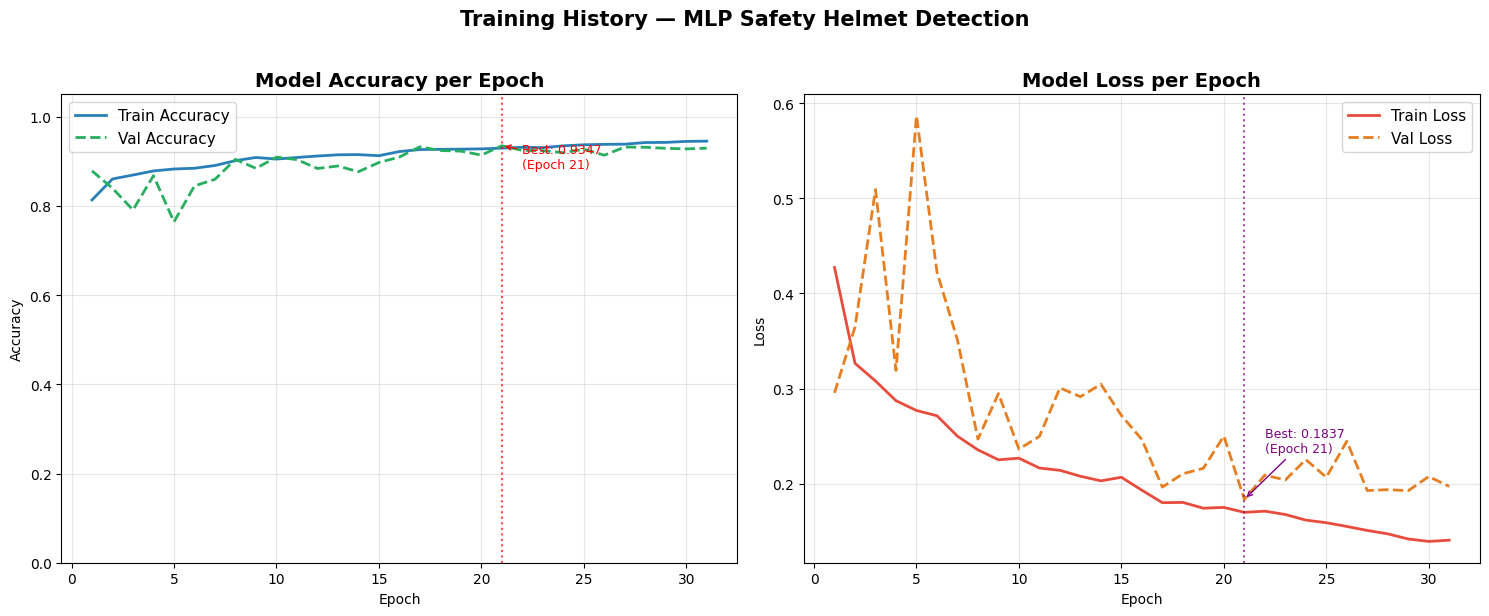

 Plot disimpan: 03_training_history.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
epochs_range = range(1, len(history.history['accuracy']) + 1)

# Accuracy
axes[0].plot(epochs_range, history.history['accuracy'],
             label='Train Accuracy', color='#2980b9', linewidth=2)
axes[0].plot(epochs_range, history.history['val_accuracy'],
             label='Val Accuracy',   color='#27ae60', linewidth=2, linestyle='--')

best_epoch_acc = np.argmax(history.history['val_accuracy']) + 1
best_val_acc   = max(history.history['val_accuracy'])
axes[0].axvline(x=best_epoch_acc, color='red', linestyle=':', alpha=0.7)
axes[0].annotate(
    f'Best: {best_val_acc:.4f}\n(Epoch {best_epoch_acc})',
    xy=(best_epoch_acc, best_val_acc),
    xytext=(best_epoch_acc + 1, best_val_acc - 0.05),
    fontsize=9, color='red',
    arrowprops=dict(arrowstyle='->', color='red')
)
axes[0].set_title('Model Accuracy per Epoch', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1.05])

# Loss
axes[1].plot(epochs_range, history.history['loss'],
             label='Train Loss', color='#e74c3c', linewidth=2)
axes[1].plot(epochs_range, history.history['val_loss'],
             label='Val Loss',   color='#e67e22', linewidth=2, linestyle='--')

best_epoch_loss = np.argmin(history.history['val_loss']) + 1
best_val_loss   = min(history.history['val_loss'])
axes[1].axvline(x=best_epoch_loss, color='purple', linestyle=':', alpha=0.7)
axes[1].annotate(
    f'Best: {best_val_loss:.4f}\n(Epoch {best_epoch_loss})',
    xy=(best_epoch_loss, best_val_loss),
    xytext=(best_epoch_loss + 1, best_val_loss + 0.05),
    fontsize=9, color='purple',
    arrowprops=dict(arrowstyle='->', color='purple')
)
axes[1].set_title('Model Loss per Epoch', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History — MLP Safety Helmet Detection',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/03_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Plot disimpan: 03_training_history.png')

# Evaluasi Model pada Test Set

 Loading model terbaik (best_model_mlp.keras)...
 Model berhasil dimuat!

 Melakukan prediksi pada test set...
 Prediksi selesai!

  HASIL EVALUASI MODEL — TEST SET
  Accuracy  (Weighted): 0.9273  (92.73%)
  Precision (Weighted): 0.9322  (93.22%)
  Recall    (Weighted): 0.9273  (92.73%)
  F1-Score  (Weighted): 0.9286  (92.86%)
  AUC-ROC: 0.9752  (97.52%)

  Metrik Per Kelas:
  Kelas                           Precision     Recall   F1-Score
  ------------------------------------------------------------
  helmet (Kelas 0)                   0.9717     0.9289     0.9498
  head (Kelas 1)                     0.8191     0.9224     0.8677

   Classification Report (Lengkap):
  --------------------------------------------------
                precision    recall  f1-score   support
  
    helmet (0)       0.97      0.93      0.95      3659
      head (1)       0.82      0.92      0.87      1276
  
      accuracy                           0.93      4935
     macro avg       0.90      0.93      

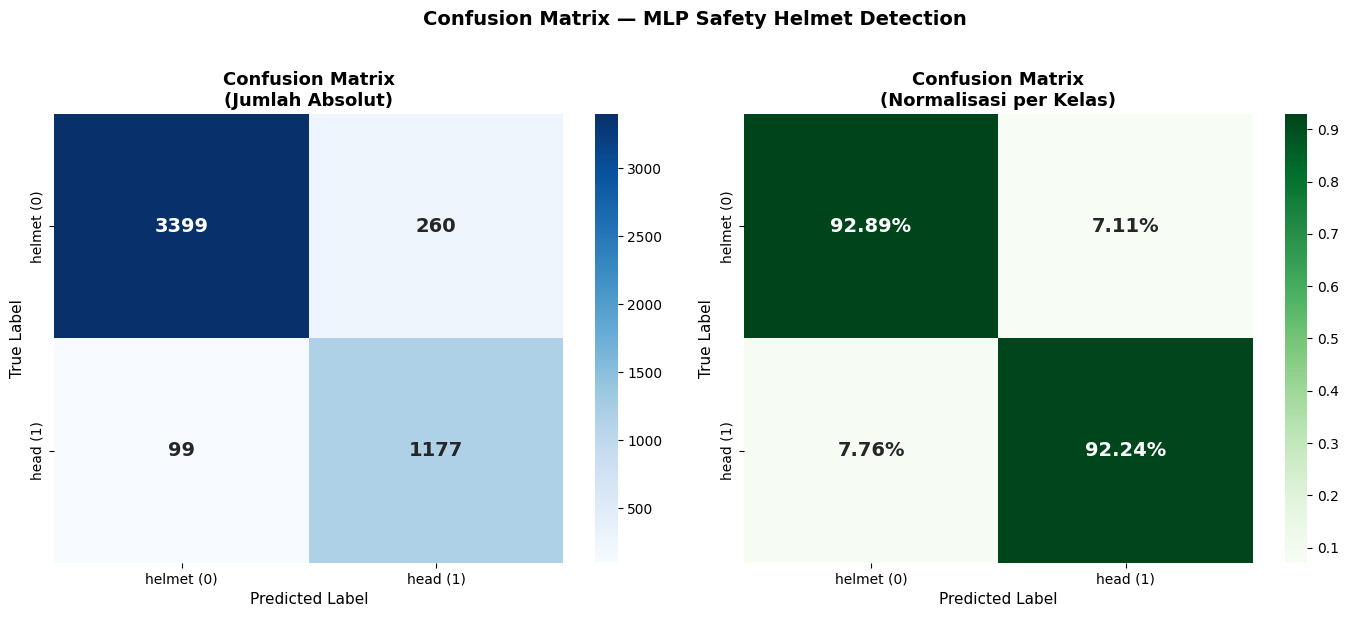

 Plot disimpan: 04_confusion_matrix.png


In [ ]:
# untuk AUC-ROC dihitung manual menggunakan roc_auc_score (sklearn) → Menghindari bug XLA tf.keras.metrics.AUC di TF 2.19/Keras 3

from sklearn.metrics import roc_auc_score

print(' Loading model terbaik (best_model_mlp.keras)...')
best_model = keras.models.load_model('/content/best_model_mlp.keras')
print(' Model berhasil dimuat!\n')

print(' Melakukan prediksi pada test set...')
y_pred_proba = best_model.predict(X_test_flat, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)
print(' Prediksi selesai!\n')

acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred,    average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred,        average='weighted', zero_division=0)

auc_score = roc_auc_score(y_test, y_pred_proba[:, 1])

precision_per = precision_score(y_test, y_pred, average=None, zero_division=0)
recall_per    = recall_score(y_test, y_pred,    average=None, zero_division=0)
f1_per        = f1_score(y_test, y_pred,        average=None, zero_division=0)

print('='*60)
print('  HASIL EVALUASI MODEL — TEST SET')
print('='*60)
print(f'  Accuracy  (Weighted): {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision (Weighted): {precision:.4f}  ({precision*100:.2f}%)')
print(f'  Recall    (Weighted): {recall:.4f}  ({recall*100:.2f}%)')
print(f'  F1-Score  (Weighted): {f1:.4f}  ({f1*100:.2f}%)')
print(f'  AUC-ROC: {auc_score:.4f}  ({auc_score*100:.2f}%)')
print('='*60)

print(f'\n  Metrik Per Kelas:')
print(f'  {"Kelas":<30} {"Precision":>10} {"Recall":>10} {"F1-Score":>10}')
print(f'  {"-"*60}')
for i, cls_name in enumerate(['helmet (Kelas 0)', 'head (Kelas 1)']):
    print(f'  {cls_name:<30} {precision_per[i]:>10.4f} {recall_per[i]:>10.4f} {f1_per[i]:>10.4f}')

print(f'\n   Classification Report (Lengkap):')
print('  ' + '-'*50)
report = classification_report(
    y_test, y_pred,
    target_names=['helmet (0)', 'head (1)'],
    zero_division=0
)
for line in report.split('\n'):
    print('  ' + line)

cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['helmet (0)', 'head (1)'],
    yticklabels=['helmet (0)', 'head (1)'],
    ax=axes[0], annot_kws={'size': 14, 'weight': 'bold'}
)
axes[0].set_title('Confusion Matrix\n(Jumlah Absolut)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Greens',
    xticklabels=['helmet (0)', 'head (1)'],
    yticklabels=['helmet (0)', 'head (1)'],
    ax=axes[1], annot_kws={'size': 14, 'weight': 'bold'}
)
axes[1].set_title('Confusion Matrix\n(Normalisasi per Kelas)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)

plt.suptitle('Confusion Matrix — MLP Safety Helmet Detection',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/04_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Plot disimpan: 04_confusion_matrix.png')

# Visualisasi Hasil Prediksi pada Sample Crop

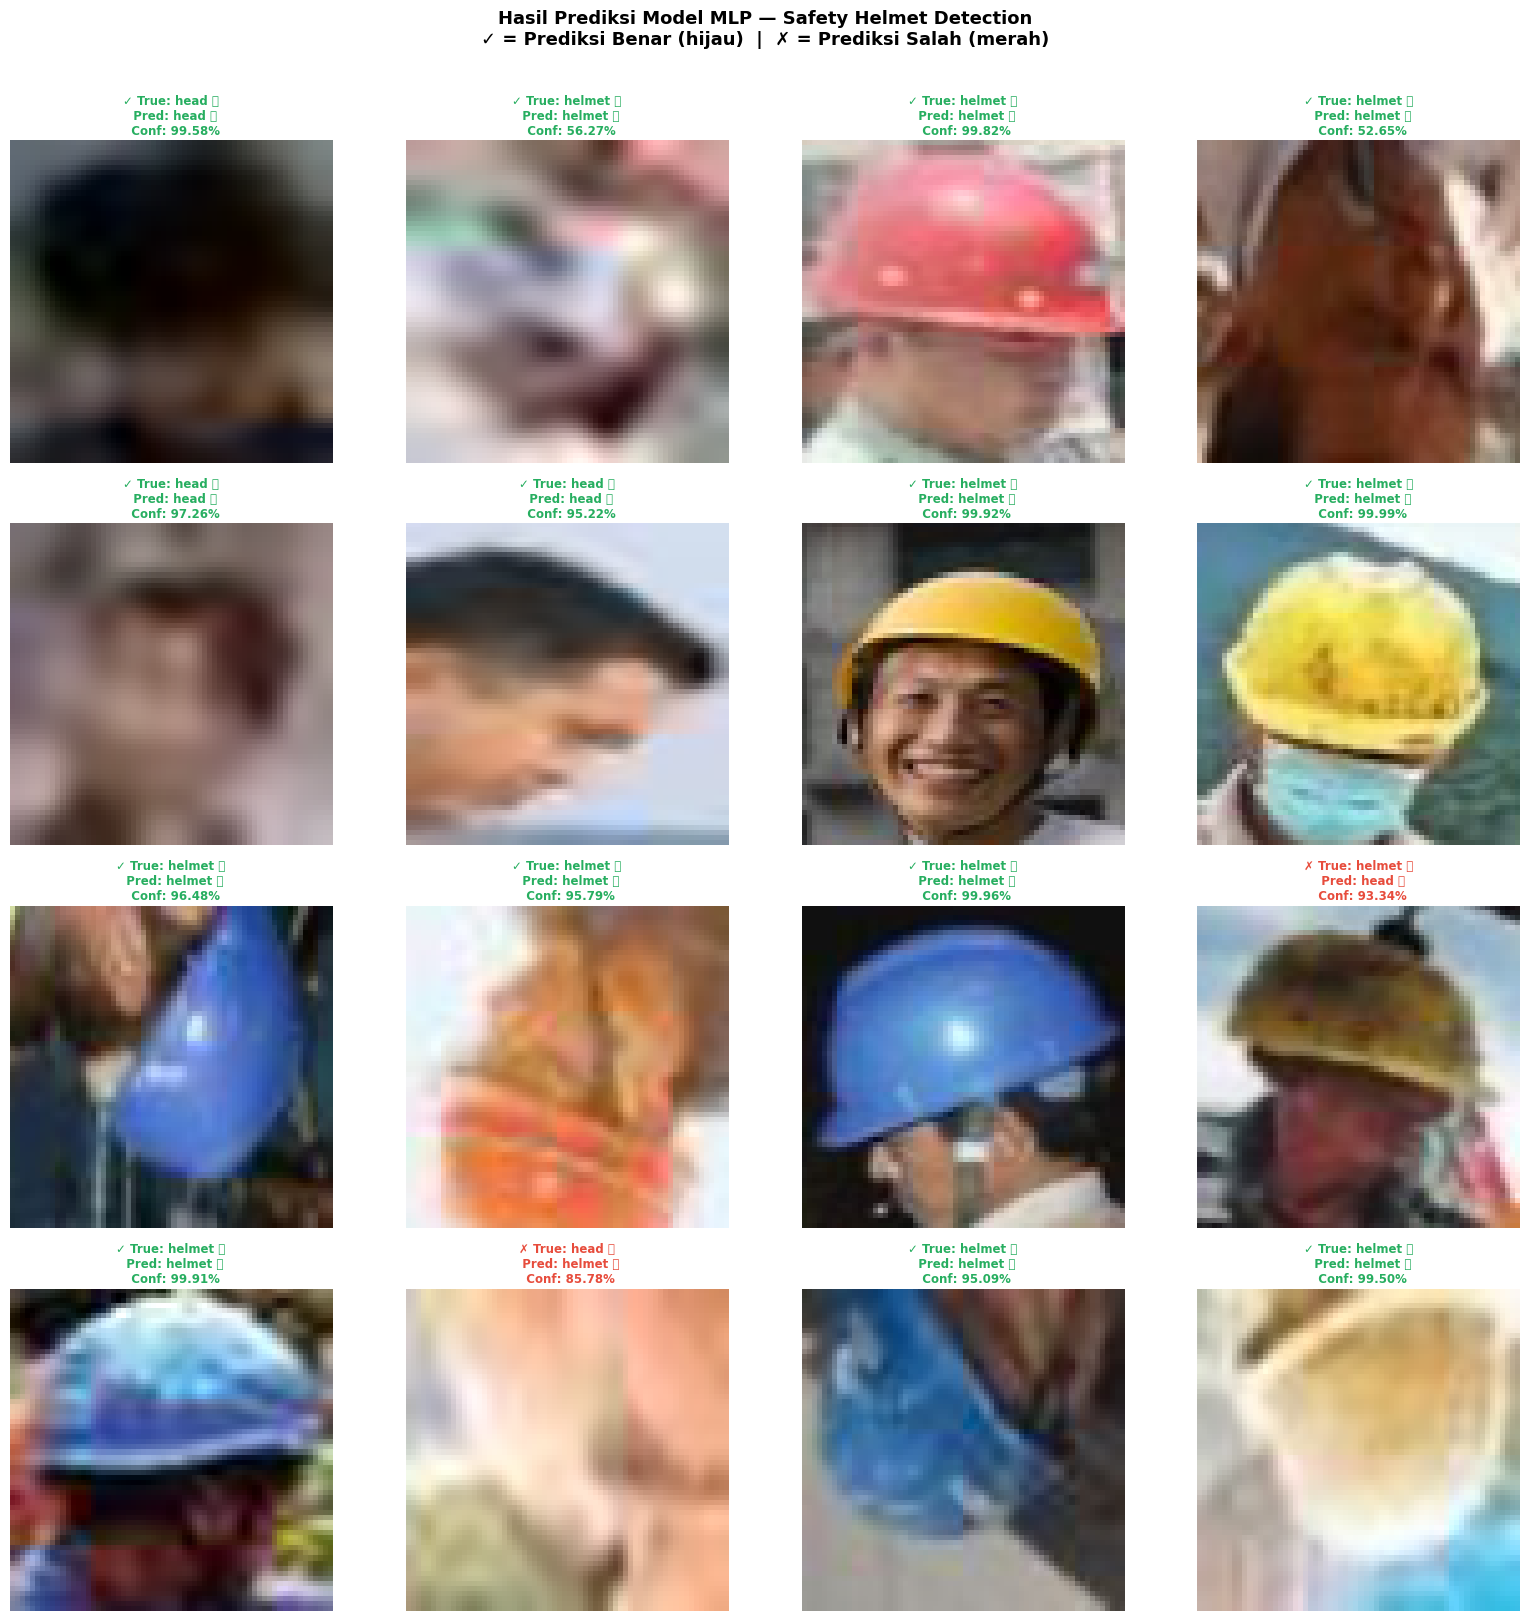

 Plot disimpan: 05_sample_prediksi.png

 Akurasi pada 16 sampel visualisasi: 87.5%


In [ ]:
np.random.seed(RANDOM_STATE)
n_samples  = 16
sample_idx = np.random.choice(len(X_test), n_samples, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i, idx in enumerate(sample_idx):
    img_show   = X_test[idx]
    true_label = y_test[idx]
    pred_label = y_pred[idx]
    pred_conf  = y_pred_proba[idx][pred_label]

    true_name  = 'helmet ' if true_label == 0 else 'head '
    pred_name  = 'helmet ' if pred_label == 0 else 'head '
    is_correct = true_label == pred_label

    axes[i].imshow(img_show)
    axes[i].axis('off')

    border_color = '#27ae60' if is_correct else '#e74c3c'
    status_icon  = '' if is_correct else ''

    title = (f'{status_icon} True: {true_name}\n'
             f'  Pred: {pred_name}\n'
             f'  Conf: {pred_conf:.2%}')

    axes[i].set_title(
        title, fontsize=8.5, fontweight='bold',
        color=border_color, pad=4
    )

    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)

plt.suptitle(
    'Hasil Prediksi Model MLP — Safety Helmet Detection\n'
    ' = Prediksi Benar (hijau)  |   = Prediksi Salah (merah)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('/content/05_sample_prediksi.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Plot disimpan: 05_sample_prediksi.png')

sample_true = y_test[sample_idx]
sample_pred = y_pred[sample_idx]
print(f'\n Akurasi pada {n_samples} sampel visualisasi: '
      f'{accuracy_score(sample_true, sample_pred)*100:.1f}%')

# Ringkasan Akhir & Simpan Model

In [ ]:
best_model.save('/content/mlp_helmet_detector_final.keras')
print(' Model disimpan: mlp_helmet_detector_final.keras')

history_df = pd.DataFrame(history.history)
history_df.index.name = 'epoch'
history_df.to_csv('/content/training_history.csv')
print(' History disimpan: training_history.csv')

metrics_df = pd.DataFrame({
    'Metric'         : ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Weighted Score' : [acc, precision, recall, f1, auc_score],
    'Percentage'     : [f'{v*100:.2f}%' for v in [acc, precision, recall, f1, auc_score]]
})
metrics_df.to_csv('/content/evaluation_metrics.csv', index=False)
print(' Metrik disimpan: evaluation_metrics.csv')

print('\n')
print('-' * 60)
print('RINGKASAN AKHIR — UAS JST (v3)')
print('Deteksi Helm Keselamatan Kerja dengan MLP')
print('-' * 60)
print('Judul    : Safety Helmet Detection (K3)')
print('Dataset  : Hard Hat Workers (Larxel/Kaggle)')
print('Model    : Multilayer Perceptron (MLP)')
print('Metode   : Feedforward + Backpropagation')
print('-' * 60)
print('PERBAIKAN YANG DITERAPKAN (v3):')
print('#1 Bounding Box Crop (bukan load gambar penuh)')
print('#2 Per-Image Split (tidak ada data leakage)')
print('#3 Cell DIAGNOSIS dihapus dari pipeline')
print('#4 AUC-ROC dihitung manual via roc_auc_score (sklearn)')
print('#5 EarlyStopping & ModelCheckpoint: monitor=val_loss')
print('-' * 60)
print('Arsitektur: Input(12288)→512→256→128→64(L2)→Output(2)')
print('Optimizer : Adam  | Loss: Sparse Cat. Crossentropy')
print(f'Epochs    : {len(history.history["accuracy"]):<5} (Early Stop)')
print('-' * 60)
print(f'HASIL EVALUASI (TEST SET):')
print(f'Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'Precision : {precision:.4f}  ({precision*100:.2f}%)')
print(f'Recall    : {recall:.4f}  ({recall*100:.2f}%)')
print(f'F1-Score  : {f1:.4f}  ({f1*100:.2f}%)')
print(f'AUC-ROC   : {auc_score:.4f}  ({auc_score*100:.2f}%)')
print('-' * 60)
print(f'CONFUSION MATRIX:')
print(f'TN (helmet→helmet): {cm[0][0]:>5}')
print(f'FP (helmet→head)  : {cm[0][1]:>5}')
print(f'FN (head→helmet)  : {cm[1][0]:>5}')
print(f'TP (head→head)    : {cm[1][1]:>5}')
print('-' * 60)
print(f'Imbalanced Handling: CLASS WEIGHT (compute_class_weight)')
print(f'helmet weight: {class_weight_dict[0]:.4f}')
print(f'head weight  : {class_weight_dict[1]:.4f}')
print('-' * 60)

print('\n File output yang dihasilkan:')
output_files = [
    '01_distribusi_label.png',
    '02_sample_gambar.png',
    '03_training_history.png',
    '04_confusion_matrix.png',
    '05_sample_prediksi.png',
    'best_model_mlp.keras',
    'mlp_helmet_detector_final.keras',
    'training_history.csv',
    'evaluation_metrics.csv',
]
for f in output_files:
    path   = f'/content/{f}'
    exists = '' if os.path.exists(path) else ''
    print(f'   {exists} {f}')

 Model disimpan: mlp_helmet_detector_final.keras
 History disimpan: training_history.csv
 Metrik disimpan: evaluation_metrics.csv



          RINGKASAN AKHIR — UAS JST (v3)                 
  Deteksi Helm Keselamatan Kerja dengan MLP               

  Judul    : Safety Helmet Detection (K3)                 
  Dataset  : Hard Hat Workers (Larxel/Kaggle)             
  Model    : Multilayer Perceptron (MLP)                  
  Metode   : Feedforward + Backpropagation                

  PERBAIKAN YANG DITERAPKAN (v3):                         
  #1 Bounding Box Crop (bukan load gambar penuh)          
  #2 Per-Image Split (tidak ada data leakage)             
  #3 Cell DIAGNOSIS dihapus dari pipeline                 
  #4 AUC-ROC dihitung manual via roc_auc_score (sklearn)  
  #5 EarlyStopping & ModelCheckpoint: monitor=val_loss    

  Arsitektur: Input(12288)→512→256→128→64(L2)→Output(2)  
  Optimizer : Adam  | Loss: Sparse Cat. Crossentropy      
  Epochs    : 31    (Early Stop)        